In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
!pip install biopython
from Bio.PDB import PDBParser
from torch.utils.data import Dataset, DataLoader
import sys
sys.path.append('scripts')

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import pdb_to_graph
import mldft_surrogate
import verify_twin_pipeline
import pdb_voxelizier
import cnn_mlp_encoder
import jw_quantum_mapper

In [3]:
class ProteinDataset(Dataset):
    def __init__(self, voxels, graphs):
        #voxels
        self.voxels = voxels
        #coefficients 
        self.graphs = graphs
    #number of proteins  
    def __len__(self):
        return len(self.voxels)
    #cinverting numpy array to tensor 
    def __getitem__(self, index):
        voxel = torch.tensor(self.voxels[index], dtype=torch.float32)
        graph = self.graphs[index]
        return voxel, graph

In [4]:
proteins = ["proteins/1ACX.pdb","proteins/1DMC.pdb","proteins/4U7S.pdb", "proteins/4UT7.pdb", "proteins/7F07.pdb", "proteins/1A7R.pdb", "proteins/1BVL.pdb", "proteins/1P7I.pdb", "proteins/3A02.pdb", "proteins/3IY6.pdb", "proteins/3K2A.pdb", "proteins/5Z2S.pdb"]
# stores input protein voxel and graphs (x,graph)
X = []
graphs = []

for pdb in proteins:
    #convert to voxel grid
    voxel = pdb_voxelizier.pdb_to_tensor(pdb, grid_size=32)
    #store voxel
    X.append(voxel[0])
    # try to get gnn input
    graph = pdb_to_graph.pdb_to_graph(pdb)
    graphs.append(graph)
X = np.array(X)
graphs = graphs

In [5]:
#creating dataloader
dataset = ProteinDataset(X,graphs)
#now automatcally loads proteins and shuffles order 
loader = DataLoader(dataset,batch_size=1,shuffle=True)

In [6]:
#create cnn and gnn
cnn_model = cnn_mlp_encoder.ProteinPhysicsEncoder(num_sites=4)
gnn_model = mldft_surrogate.MLDFT_GNN(num_sites = 4)
#print(cnn_model)

In [7]:
gnn_model.eval()
for param in gnn_model.parameters():
    param.requires_grad = False

In [8]:
#mean squared error : helps keep error positive 
criterion = nn.MSELoss()
#just using adam for now
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

In [9]:
#training loop
#epoch = iterations 
epochs = 200
loss_history = []
for epoch in range(epochs):
    #track loss
    total_loss = 0
    for voxel, graph in loader:
        #instead gnn creates target 
        with torch.no_grad():
            target = gnn_model(graph)
            target = torch.mean(target,dim=0,keepdim=True)
        # cnn prediction
        prediction = cnn_model(voxel)
        # Compare prediction with target coefficients 
        loss = criterion(prediction,target)
        # remove old gradients 
        optimizer.zero_grad()
        #calculate how values should change
        loss.backward()
        #update values 
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    loss_history.append(total_loss)
    #Note: ideally loss should decrease overtime
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.6f}")

Epoch 1/200, Loss: 0.440593
Epoch 2/200, Loss: 0.078790
Epoch 3/200, Loss: 0.013411
Epoch 4/200, Loss: 0.008821
Epoch 5/200, Loss: 0.006524
Epoch 6/200, Loss: 0.003721
Epoch 7/200, Loss: 0.002811
Epoch 8/200, Loss: 0.003322
Epoch 9/200, Loss: 0.001725
Epoch 10/200, Loss: 0.001705
Epoch 11/200, Loss: 0.001125
Epoch 12/200, Loss: 0.000754
Epoch 13/200, Loss: 0.000660
Epoch 14/200, Loss: 0.000468
Epoch 15/200, Loss: 0.000329
Epoch 16/200, Loss: 0.000264
Epoch 17/200, Loss: 0.000280
Epoch 18/200, Loss: 0.000289
Epoch 19/200, Loss: 0.000178
Epoch 20/200, Loss: 0.000215
Epoch 21/200, Loss: 0.000340
Epoch 22/200, Loss: 0.000329
Epoch 23/200, Loss: 0.000360
Epoch 24/200, Loss: 0.000455
Epoch 25/200, Loss: 0.000442
Epoch 26/200, Loss: 0.000584
Epoch 27/200, Loss: 0.000731
Epoch 28/200, Loss: 0.000726
Epoch 29/200, Loss: 0.000472
Epoch 30/200, Loss: 0.000302
Epoch 31/200, Loss: 0.000095
Epoch 32/200, Loss: 0.000126
Epoch 33/200, Loss: 0.000111
Epoch 34/200, Loss: 0.000101
Epoch 35/200, Loss: 0.0

In [11]:
torch.save(cnn_model.state_dict(),"protein_cnn2.pth")

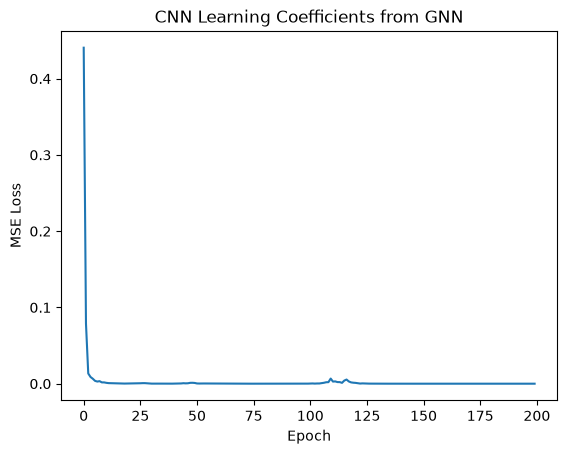

In [10]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CNN Learning Coefficients from GNN")
plt.show()